# Visualize generative performance with NCT00113763 dataset 

In [1]:
import pandas as pd
import torch
import os
import sys
from pathlib import Path
module_path = Path.cwd().parent / 'utils'
sys.path.append(str(module_path))
import data_processing, visualization
module_path = Path.cwd().parent / 'execute'
sys.path.append(str(module_path))

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

## 1. Original data loading, analysis and visualization

### 1.1. Experiment setting - links to data

In [2]:
dataset_name = "NCT00113763"
current_path = os.getcwd()  # Get current working directory
parent_path = os.path.dirname(current_path)
data_file_control= parent_path + "/dataset/" + dataset_name + "/data_control.csv"
feat_types_file_control = parent_path + "/dataset/" + dataset_name + "/data_types_control.csv"
data_file_treated= parent_path + "/dataset/" + dataset_name + "/data_treated.csv"
feat_types_file_treated= parent_path + "/dataset/" + dataset_name + "/data_types_treated.csv"

# If the dataset has no missing data, leave the "miss_file" variable empty
m_perc = 10
mask = 1
miss_file = "dataset/" + dataset_name + "/Missing{}_{}.csv".format(m_perc, mask)
true_miss_file = None

### 1.2. Loading, feature analysis, and visualization of original data: control vs treated group

In [3]:
control_fnames = ['time', 'censor'] + pd.read_csv(feat_types_file_control)["name"].to_list()[1:]
control = pd.read_csv(data_file_control, header=None, names=control_fnames)
print(control.head())

    time  censor  SEX   AGE  RACCAT  PRBEV  PROXAL  B_METACT  B_LDHNM  \
0   15.0     0.0    1  22.0       1      1       1         2    399.0   
1  233.0     1.0    1  20.0       1      1       1         2    340.0   
2  882.0     1.0    1  32.0       1      1       1         1    168.0   
3   51.0     1.0    1  48.0       1      0       1         2     82.0   
4  110.0     1.0    0  37.0       1      0       1         2    460.0   

   BECOGICD  DIAGTYPE  PRADJYN  LIVERMET  KRAS  
0       1.0         0        0         1     0  
1       0.0         1        0         1     2  
2       0.0         0        0         1     2  
3       1.0         1        0         1     1  
4       2.0         0        0         1     1  


In [4]:
# Load and transform control data
df_init_control_encoded, feat_types_dict, miss_mask_control, true_miss_mask_control, _ = data_processing.read_data(data_file_control, feat_types_file_control, miss_file, true_miss_file)
data_init_control_encoded = torch.from_numpy(df_init_control_encoded.values)
data_init_control = data_processing.discrete_variables_transformation(data_init_control_encoded, feat_types_dict)

# Load and transform treated data
df_init_treated_encoded, _, _, _, _ = data_processing.read_data(data_file_treated, feat_types_file_treated, miss_file, true_miss_file)
data_init_treated_encoded = torch.from_numpy(df_init_treated_encoded.values)
data_init_treated = data_processing.discrete_variables_transformation(data_init_treated_encoded, feat_types_dict)

In [5]:
# Format data in dataframe
df_init_treated = pd.DataFrame(data_init_treated.numpy(), columns=control_fnames)
df_init_control = pd.DataFrame(data_init_control.numpy(), columns=control_fnames)

# Update dataframe
df_init_treated["treatment"] = 1
df_init_control["treatment"] = 0
df_init = pd.concat([df_init_control, df_init_treated], ignore_index=True)

## 2. Training and generation from the generative model

Possible generative models: HI-VAE (our), survival_gan, survival_ctgan, survival_nflow, survae (synthcity)

In [6]:
import surv_hivae, surv_gan, surv_vae
generators_dict = {"HI-VAE_weibull" : surv_hivae,
                    "HI-VAE_piecewise" : surv_hivae,
                    "Surv-GAN" : surv_gan,
                    "Surv-VAE" : surv_vae}



[KeOps] Warning : omp.h header is not in the path, disabling OpenMP. To fix this, you can set the environment
                  variable OMP_PATH to the location of the header before importing keopscore or pykeops,
                  e.g. using os.environ: import os; os.environ['OMP_PATH'] = '/path/to/omp/header'
[KeOps] Warning : Cuda libraries were not detected on the system or could not be loaded ; using cpu only mode


In [7]:
# the datasets used for training is data_init_control
import json
import os
name_config = dataset_name
# best_param_files = [f for f in os.listdir("optuna_results") if (f.endswith('.json') & (name_config in f))]

generators_sel = ["HI-VAE_weibull", "HI-VAE_piecewise", "Surv-GAN", "Surv-VAE"]

best_params_dict = {}
for generator_name in generators_sel:
    # best_param_file = [item for item in best_param_files if generator_name in item][0]
    for f in os.listdir(parent_path + "/dataset/" + dataset_name + "/optuna_results"):
        if (f.endswith(generator_name + '.json') & (name_config in f)):
            best_param_file = f
    with open(parent_path + "/dataset/" + dataset_name + "/optuna_results/" + best_param_file, "r") as f:
        best_params_dict[generator_name] = json.load(f)

n_generated_dataset = 100
data_gen_control_dict = {}
for generator_name in generators_sel:
    print("=" * 100)
    print("Generate data by " + generator_name)
    best_params = best_params_dict[generator_name]
    if generator_name in ["HI-VAE_weibull", "HI-VAE_piecewise"]:
            feat_types_dict_ext = feat_types_dict.copy()
            for i in range(len(feat_types_dict)):
                if feat_types_dict_ext[i]['name'] == "survcens":
                    if generator_name in["HI-VAE_weibull"]:
                        feat_types_dict_ext[i]["type"] = 'surv_weibull'
                    else:
                        feat_types_dict_ext[i]["type"] = 'surv_piecewise'
    if generator_name in ["HI-VAE_weibull", "HI-VAE_piecewise"]:
        data_gen_control_dict[generator_name] = generators_dict[generator_name].run(df_init_control_encoded, miss_mask_control, true_miss_mask_control, feat_types_dict_ext, n_generated_dataset, params=best_params, epochs = 10000)
    else:
        data_gen_control_dict[generator_name] = generators_dict[generator_name].run(data_init_control, columns=control_fnames, target_column="censor", time_to_event_column="time", n_generated_dataset=n_generated_dataset, params=best_params)

Generate data by HI-VAE_weibull
Epoch: [ 0]  time: 0.1213, ELBO_train: -21.84774505, KL_z: 3.37940168, KL_s: 0.06009187, reconstruction loss: -18.40825149
Epoch: [100]  time: 4.5940, ELBO_train: -16.05765449, KL_z: 0.53231267, KL_s: 1.00135325, reconstruction loss: -14.52398856
Epoch: [200]  time: 9.0343, ELBO_train: -16.38080088, KL_z: 0.86849845, KL_s: 0.14278637, reconstruction loss: -15.36951606
Epoch: [300]  time: 13.5178, ELBO_train: -16.41681798, KL_z: 0.94267879, KL_s: 0.02975275, reconstruction loss: -15.44438644
Epoch: [400]  time: 18.1351, ELBO_train: -16.45437453, KL_z: 0.92134433, KL_s: 0.02163662, reconstruction loss: -15.51139357
Epoch: [500]  time: 22.6437, ELBO_train: -16.37902811, KL_z: 0.96783272, KL_s: 0.01569768, reconstruction loss: -15.39549770
Early stopping at epoch 550.
Training finished.
Generate data by HI-VAE_piecewise
Epoch: [ 0]  time: 0.0557, ELBO_train: -19.74421716, KL_z: 0.61757156, KL_s: 0.07210544, reconstruction loss: -19.05454016
Epoch: [100]  tim

[2026-07-07T14:47:08.039254+0200][56583][CRITICAL] module disabled: /opt/anaconda3/envs/env_synthcity/lib/python3.11/site-packages/synthcity/plugins/generic/plugin_goggle.py
[2026-07-07T14:47:09.648544+0200][56583][CRITICAL] module disabled: /opt/anaconda3/envs/env_synthcity/lib/python3.11/site-packages/synthcity/plugins/generic/plugin_goggle.py
  3%|▎         | 299/10000 [00:05<03:02, 53.12it/s]
[2026-07-07T14:48:16.944642+0200][56583][CRITICAL] module disabled: /opt/anaconda3/envs/env_synthcity/lib/python3.11/site-packages/synthcity/plugins/generic/plugin_goggle.py
[2026-07-07T14:48:16.967061+0200][56583][CRITICAL] module disabled: /opt/anaconda3/envs/env_synthcity/lib/python3.11/site-packages/synthcity/plugins/generic/plugin_goggle.py


Generate data by Surv-VAE


100%|██████████| 500/500 [00:05<00:00, 83.43it/s]


In [8]:
# Convert generated data into dataframe
df_gen_control_dict = {}
df_syn_dict = {}
for generator_name in generators_sel:
    list_df_gen_control = []
    data_syn = []
    for j in range(n_generated_dataset):
        df_gen_control_j = pd.DataFrame(data_gen_control_dict[generator_name][j].numpy(), columns=control_fnames)
        df_gen_control_j['treatment'] = 0
        list_df_gen_control.append(df_gen_control_j)
        data_syn.append(pd.concat([df_init_treated, df_gen_control_j], ignore_index=True))
        
    df_gen_control_dict[generator_name] = list_df_gen_control
    df_syn_dict[generator_name] = data_syn

### 3. Compare generation performance

#### 3.1. General metrics

In [9]:
from metrics import general_metrics
general_scores = []
for generator_name in generators_sel:
    general_scores.append(general_metrics(df_init_control, df_gen_control_dict[generator_name], generator_name))
general_scores_df = pd.concat(general_scores)

##### 3.1.1. Data resemblance

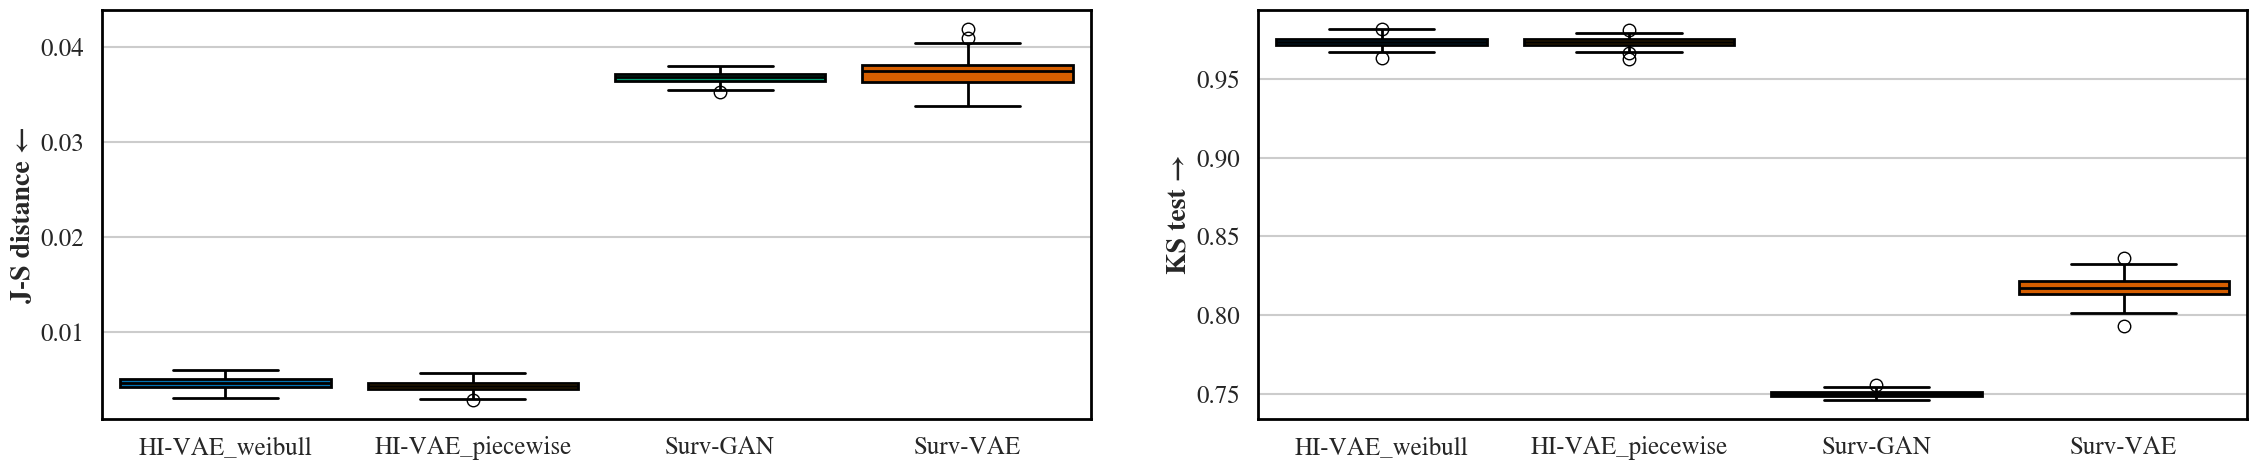

In [10]:
from visualization import visualize_general_perf
visualize_general_perf(general_scores_df, metrics=[['J-S distance', "min"], ['KS test', "max"]])

##### 3.1.2. Utility

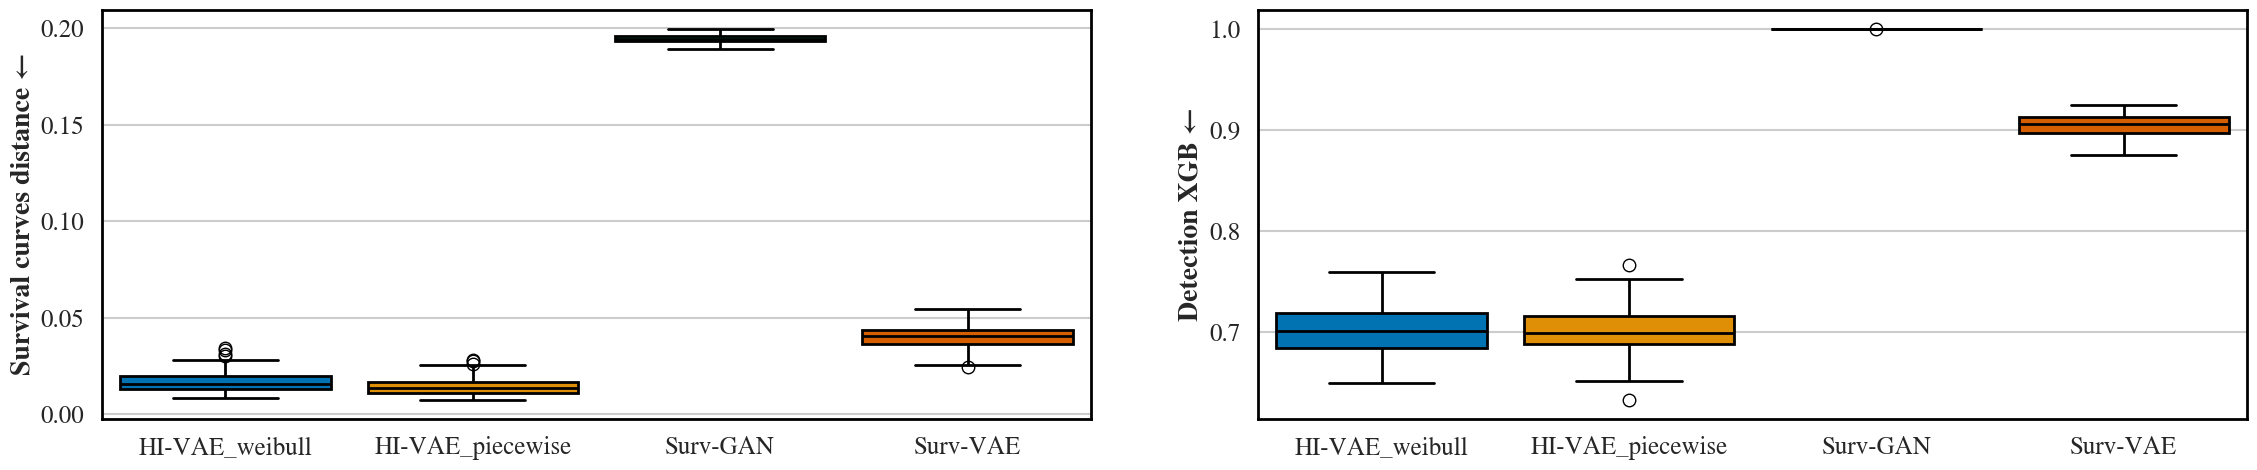

In [11]:
visualize_general_perf(general_scores_df, metrics=[['Survival curves distance', "min"], ['Detection XGB', "min"]])

#### 3.1.3. Privacy

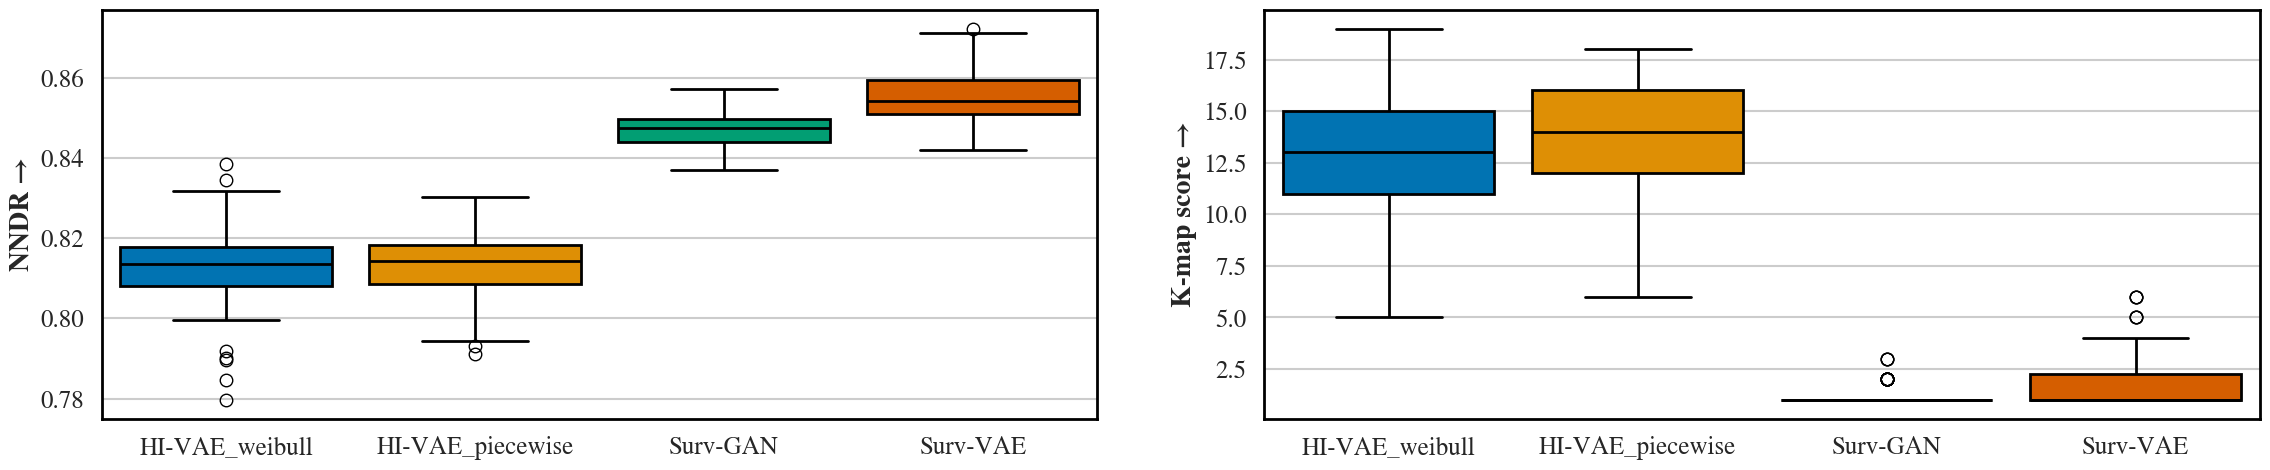

In [12]:
visualize_general_perf(general_scores_df, metrics=[['NNDR', "max"], ['K-map score', "max"]])

#### Replicability metrics

In [13]:
from metrics import replicability_ext
replicability_scores = []
for generator_name in generators_sel:
    replicability_scores.append(replicability_ext(df_init, df_syn_dict[generator_name], generator_name))
replicability_scores_df = pd.concat(replicability_scores, ignore_index=True)

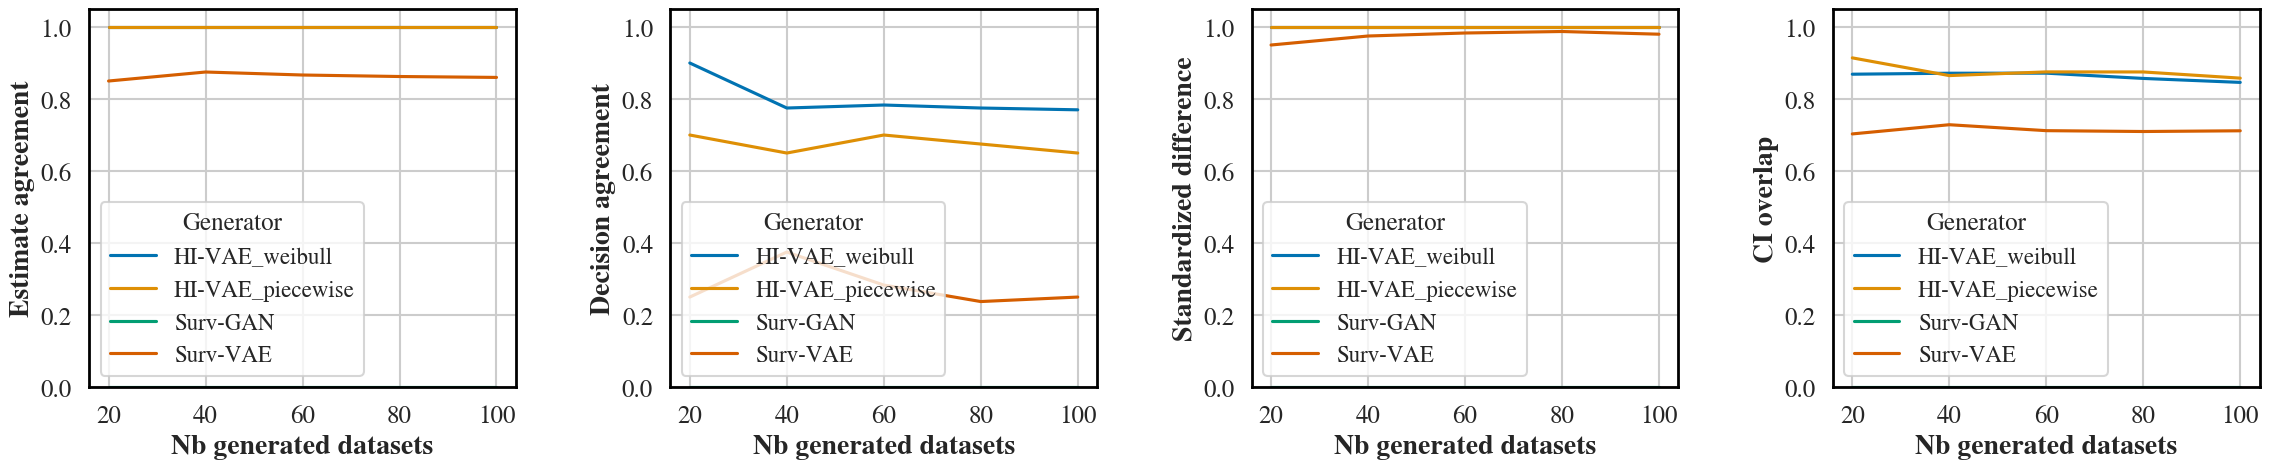

In [14]:
from visualization import visualize_replicability_perf
visualize_replicability_perf(replicability_scores_df)

In [15]:
from metrics import fit_cox_model
import numpy as np
columns = ['time', 'censor', 'treatment']
coef_init, _, ci_init, se_init = fit_cox_model(df_init, columns)
# Compute midpoints and widths
midpoints = [(ci_init[1] + ci_init[0]) / 2]
errors = [(ci_init[1] - ci_init[0]) / 2]
label = ["Init"]
colors = ['green', 'blue', 'orange', 'cyan']

colors_ = ['red']
for i , generator in enumerate(generators_sel):
    data_syn_ = df_syn_dict[generator]
    results = [fit_cox_model(data, columns) for data in data_syn_]
    coef_syn, _, _, se_syn = zip(*results)
    for n in range(10):
        coef_syn_, se_syn_ = np.array(coef_syn)[n][0], np.array(se_syn)[n][0]
        ci_syn = (coef_syn_ - 1.96 * se_syn_, coef_syn_ + 1.96 * se_syn_)
        midpoints.append((ci_syn[1] + ci_syn[0]) / 2)
        errors.append((ci_syn[1] - ci_syn[0]) / 2)
        label.append(generator + " " + str(n + 1))
        colors_.append(colors[i])

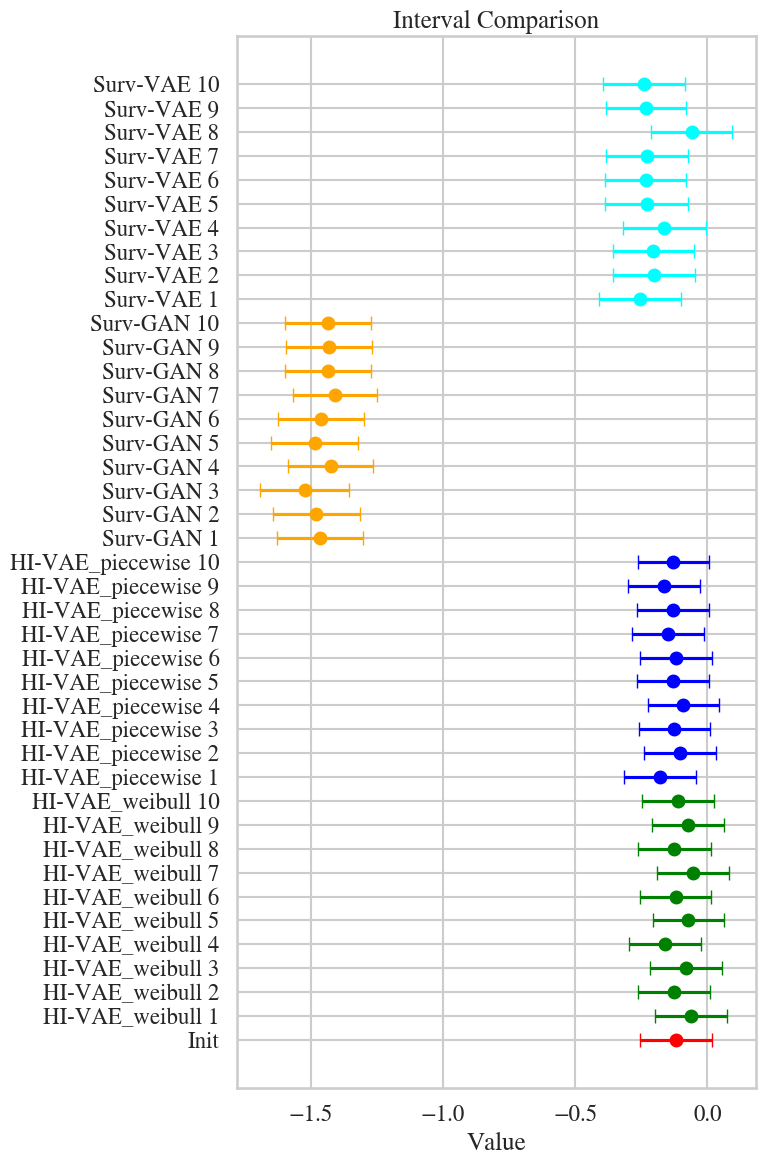

In [16]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 12))

# Plot as horizontal error bars
for i, (mid, err) in enumerate(zip(midpoints, errors)):
    ax.errorbar(x=mid, y=i, xerr=err, fmt='o', capsize=5, color=colors_[i])

plt.yticks(range(len(midpoints)), label)
plt.xlabel("Value")
plt.title("Interval Comparison")
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
from metrics import general_metrics_modular

continuous_variables_control = [row['name'] for row in feat_types_dict if row['type'] in ['pos', 'real']]
categorical_variables_control = [row['name'] for row in feat_types_dict if row['type'] in ['cat']]
simple_score_metrics = {'stats': ['jensenshannon_dist', 'survival_km_distance'],
                        'detection': ['detection_xgb'],
                        'privacy': ['k-map', 'identifiability_score']}



list_score_dfs = []
for i in range(100):
    sample_dataset = df_init_control.sample(frac=.5, random_state=i)
    leftout_dataset = df_init_control.iloc[[k for k in range(len(df_init_control)) if k not in list(sample_dataset.index)]]
    score_df_test_i = general_metrics_modular(leftout_dataset, [sample_dataset], 'hivae', simple_score_metrics, include_nndr=True,
                                              include_tableone_min_p_value=True, categorical=categorical_variables_control,
                                              continuous=continuous_variables_control, nonnormal=continuous_variables_control)
    list_score_dfs.append(score_df_test_i)

self_score_df = pd.concat(list_score_dfs)
self_score_df = self_score_df.reset_index(drop=True)
self_score_df['generator'] = 'self'
self_score_df

,J-S distance,Survival curves distance,Detection XGB,K-map score,Identifiability score,NNDR,TableOne min p-value,generator
0,0.007814,0.035083,0.450889,1.0,0.481013,0.849354,0.004000,self
1,0.007490,0.023489,0.521284,4.0,0.489451,0.854240,0.028000,self
2,0.006660,0.027799,0.495700,5.0,0.481013,0.860882,0.062000,self
3,0.006256,0.021260,0.458901,9.0,0.443038,0.838775,0.031000,self
4,0.006849,0.030951,0.493190,1.0,0.464135,0.842783,0.092000,self
...,...,...,...,...,...,...,...,...
95,0.006820,0.014965,0.434386,3.0,0.493671,0.859267,0.024000,self
96,0.008232,0.045796,0.473161,1.0,0.510549,0.852469,0.038000,self
97,0.008367,0.047262,0.498371,8.0,0.506329,0.845478,0.041408,self
98,0.007895,0.034604,0.406772,2.0,0.506329,0.845079,0.165000,self


In [20]:

_round_cols = continuous_variables_control + ['time']
_round_step = data_processing.infer_rounding_steps(df_init_control, _round_cols, coverage=0.99)
_round_floor = {c: df_init_control[c].min() for c in _round_step}
list_df_gen_control_rounded = [
    data_processing.round_to_initial_grid(df, _round_step, _round_floor)
    for df in list_df_gen_control]
score_df_rounded = general_metrics_modular(df_init_control, list_df_gen_control_rounded, 'hivae', simple_score_metrics,
                                           include_nndr=True, include_tableone_min_p_value=True, categorical=categorical_variables_control,
                                           continuous=continuous_variables_control, nonnormal=continuous_variables_control)

In [26]:
score_df_rounded_and_self = pd.concat([general_scores_df, self_score_df], ignore_index=True)

In [27]:
from visualization import visualize_grouped_perf
dict_metrics = {"Fidelity": [["J-S distance", "min"], ["Detection XGB", "min"]],
                "Utility": [["Survival curves distance", "min"], ['TableOne min p-value', 'max']],
                "Privacy": [["K-map score", "max"], ["Identifiability score", "min"], ["NNDR", "max"]]}

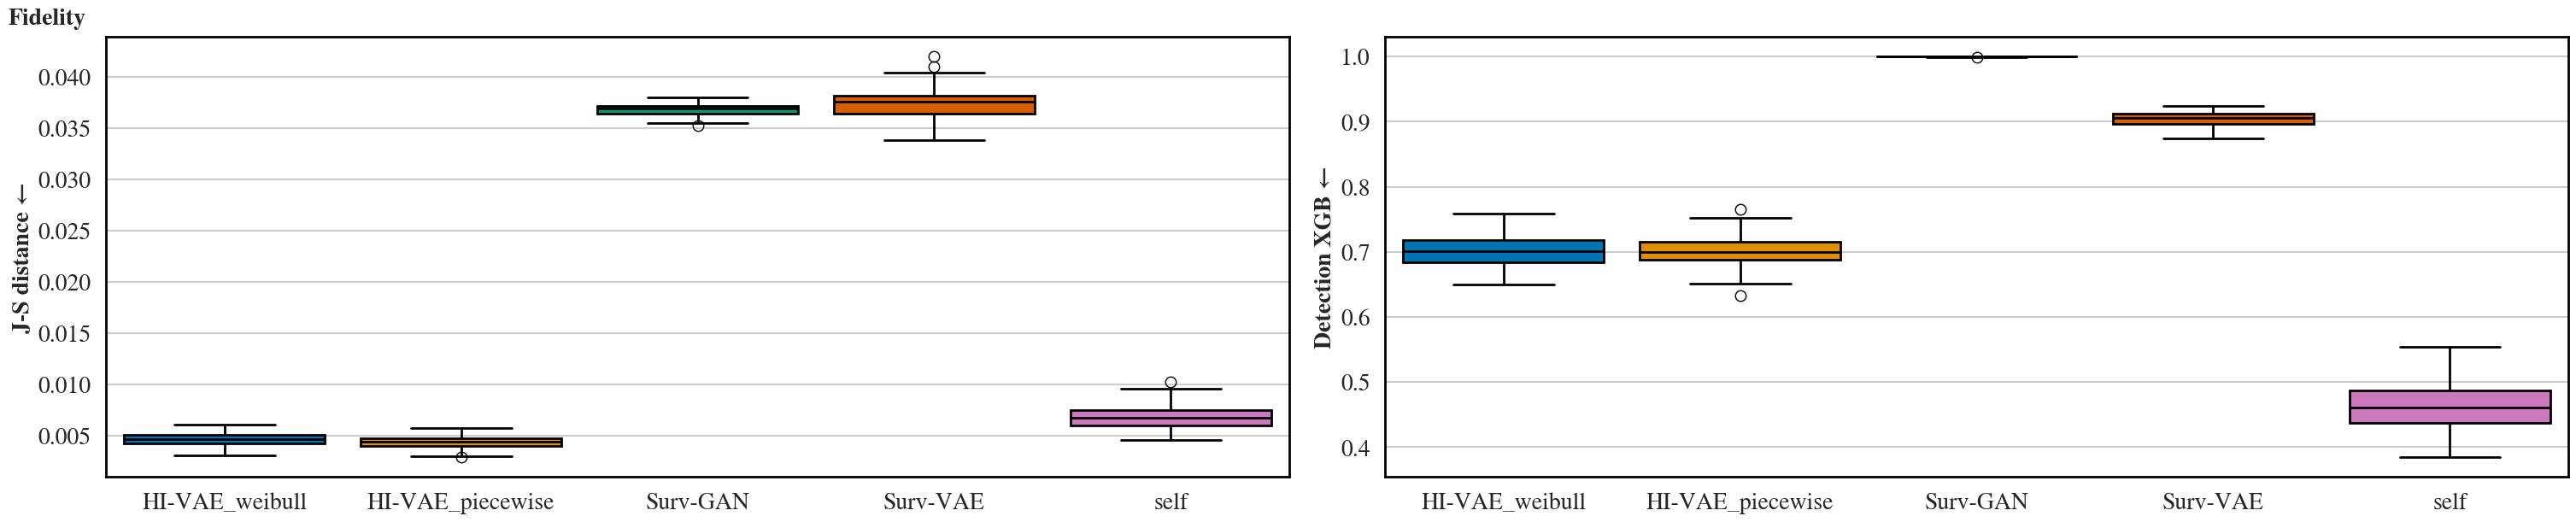

In [28]:
visualize_grouped_perf(score_df_rounded_and_self, {"Fidelity": dict_metrics["Fidelity"]})

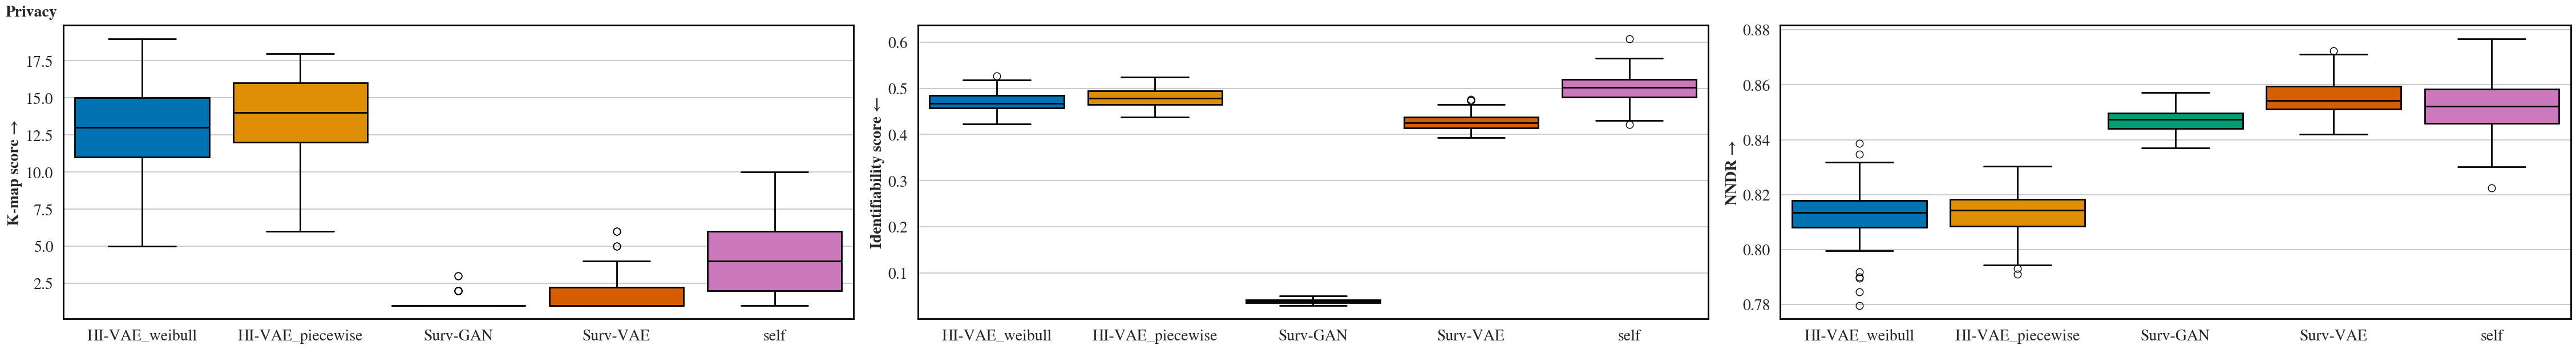

In [29]:
visualize_grouped_perf(score_df_rounded_and_self, {"Privacy": dict_metrics["Privacy"]})

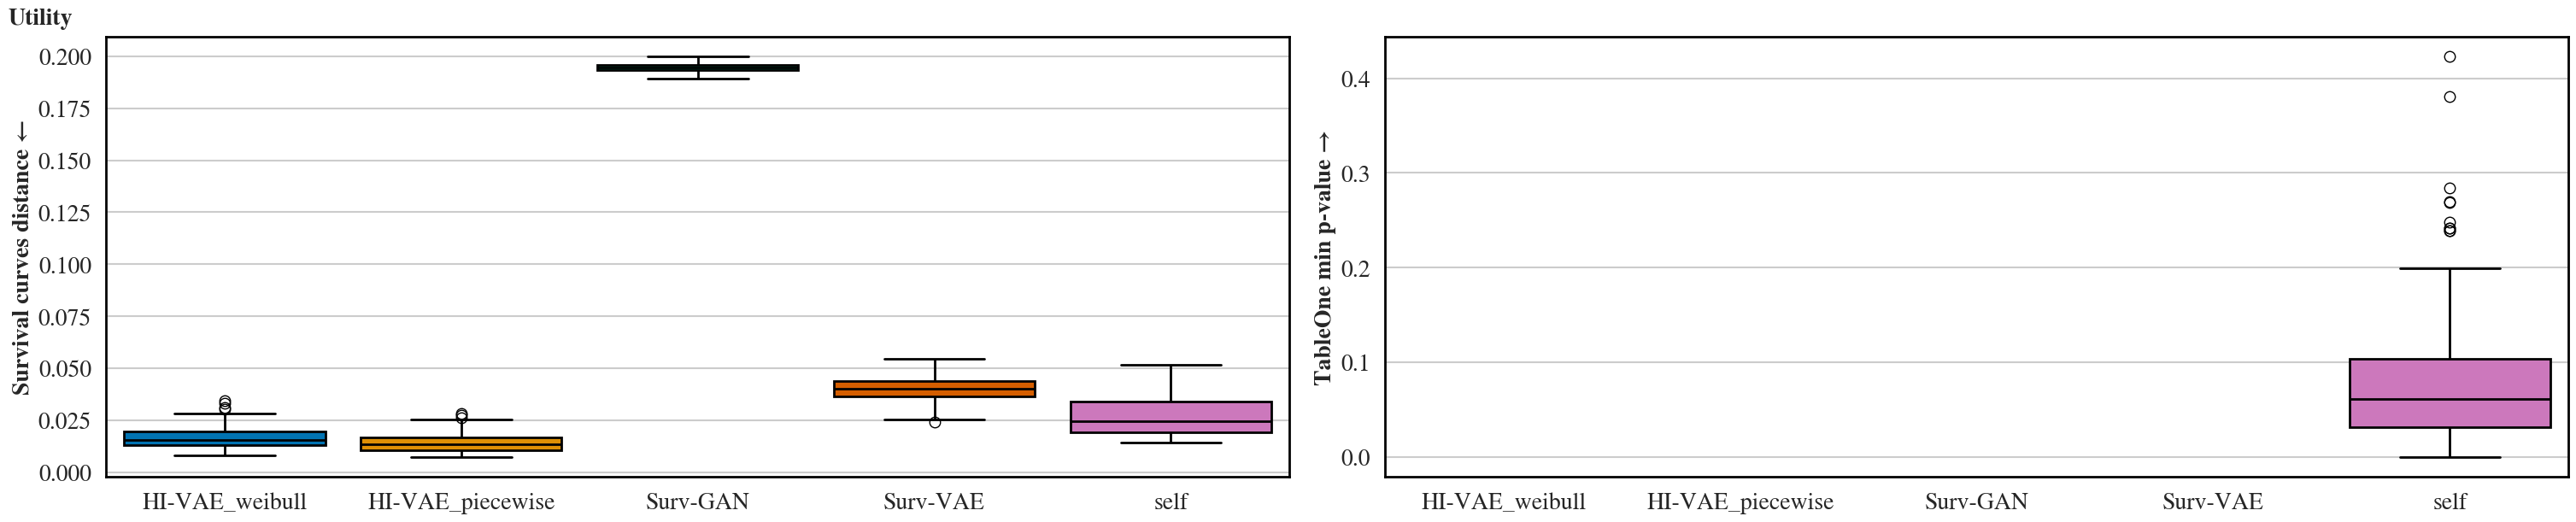

In [30]:
visualize_grouped_perf(score_df_rounded_and_self, {"Utility": dict_metrics["Utility"]})
